In [3]:
import pandas as pd
import os
from zipfile import ZipFile
import tensorflow as tf
import os
import cv2
import imghdr
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'cv2'

In [2]:
with ZipFile('/content/Images.zip','r') as zipobj:
  zipobj.extractall(r"C:\Users\Dell 7490\OneDrive\Desktop\papa world")

In [3]:
df= pd.read_csv('train_data_2024.csv')
df.head()

,FileName,Class,MoreThanOnePerson,HighLevelCategory
0,Img_460.jpg,blowing_bubbles,YES,Social_LeisureActivities
1,Img_8152.jpg,blowing_bubbles,YES,Social_LeisureActivities
2,Img_9056.jpg,jumping,YES,Sports_Recreation
3,Img_3880.jpg,pushing_a_cart,YES,OutdoorActivities
4,Img_3168.jpg,writing_on_a_book,NO,Artistic_MusicalActivities


I split the dataframe into test and train df.I took 80% percent of each class in train df so that every class is present.And then I saved it in the respective csv files.

In [4]:
train_df = pd.DataFrame()
test_df = pd.DataFrame()

# Group the DataFrame by 'Class'
grouped = df.groupby('Class')

# Iterate through each class group
for name, group in grouped:
    # Split each group into train and test sets
    train_group, test_group = train_test_split(group, test_size=0.2, random_state=42)

    # Append the split groups to the respective DataFrames
    train_df = pd.concat([train_df, train_group], ignore_index=True)
    test_df = pd.concat([test_df, test_group], ignore_index=True)

# Save the train and test DataFrames to CSV files if needed
train_df.to_csv('train_data_2024_train.csv', index=False)
test_df.to_csv('train_data_2024_test.csv', index=False)

In [5]:
df  = pd.read_csv('train_data_2024_train.csv')
df

,FileName,Class,MoreThanOnePerson,HighLevelCategory
0,Img_1833.jpg,applauding,YES,Social_LeisureActivities
1,Img_9481.jpg,applauding,NO,Social_LeisureActivities
2,Img_4182.jpg,applauding,YES,Social_LeisureActivities
3,Img_4146.jpg,applauding,YES,Social_LeisureActivities
4,Img_244.jpg,applauding,YES,Social_LeisureActivities
...,...,...,...,...
3577,Img_612.jpg,writing_on_a_book,NO,Artistic_MusicalActivities
3578,Img_1164.jpg,writing_on_a_book,NO,Artistic_MusicalActivities
3579,Img_711.jpg,writing_on_a_book,YES,Artistic_MusicalActivities
3580,Img_2851.jpg,writing_on_a_book,NO,Artistic_MusicalActivities


In [6]:
i = os.listdir(r"C:\Users\Dell 7490\OneDrive\Desktop\papa world/Images")

**CHECKING FOR CLASS IMBALANCE**

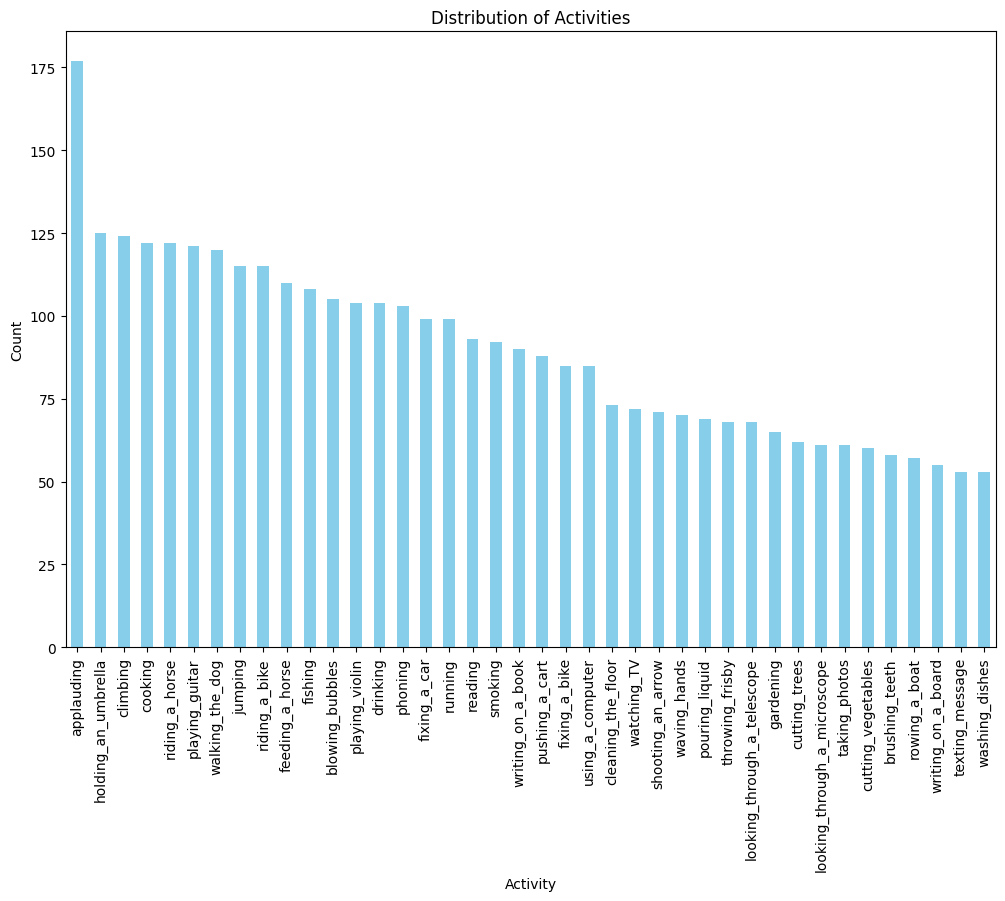

In [7]:
value_counts = df['Class'].value_counts()
plt.figure(figsize=(12, 8))
value_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Activities')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x labels to fit them better
plt.show()

WE can clearly see there is definately a class imbalance in the 'Class' column as applauding is way higher than any other class

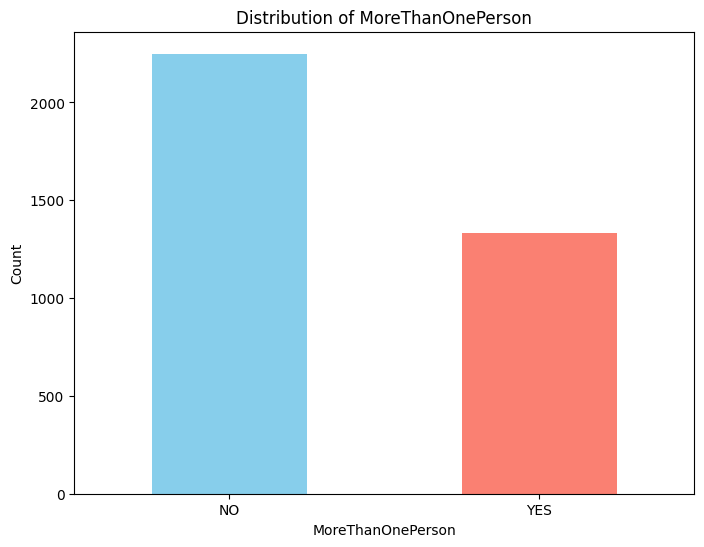

In [8]:
#Checking for MoreThanOnePerson column Imbalance
value_counts = df['MoreThanOnePerson'].value_counts()
plt.figure(figsize=(8, 6))
value_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of MoreThanOnePerson')
plt.xlabel('MoreThanOnePerson')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Clear Imbalance in this target column as 'NO' is significantly higher than 'YES' and this above two columns needs to be balanced to prevent bias towards particular class.


In [9]:
df = df[['FileName','Class','MoreThanOnePerson']]
df.head()

,FileName,Class,MoreThanOnePerson
0,Img_1833.jpg,applauding,YES
1,Img_9481.jpg,applauding,NO
2,Img_4182.jpg,applauding,YES
3,Img_4146.jpg,applauding,YES
4,Img_244.jpg,applauding,YES


In [10]:
x = df[['FileName']]
y = df[['Class','MoreThanOnePerson']]

In [11]:
!pip install imbalanced-learn
from imblearn.over_sampling import RandomOverSampler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 1.9 MB/s eta 0:00:00


In [12]:
#Oversampling
ros = RandomOverSampler(random_state=42)
y_combined = y['Class'] + '-' + y['MoreThanOnePerson']

# Fitting and resampling the dataset
X_resampled, y_resampled_combined = ros.fit_resample(x, y_combined)

# Split the combined column back into 'Class' and 'MoreThanOnePerson'
y_resampled = y_resampled_combined.str.split('-', expand=True)
y_resampled.columns = ['Class', 'MoreThanOnePerson']

# Combine resampled X and y into a new DataFrame
df_resampled = pd.concat([X_resampled, y_resampled], axis=1)

In the provided code above, RandomOverSampler is used to address class imbalance in a dataset with two target variables, Class and MoreThanOnePerson. By combining these into a single column, the sampler balances the dataset by creating synthetic samples for underrepresented combinations. After resampling, the combined column is split back into the original target variables. This results in a balanced dataset

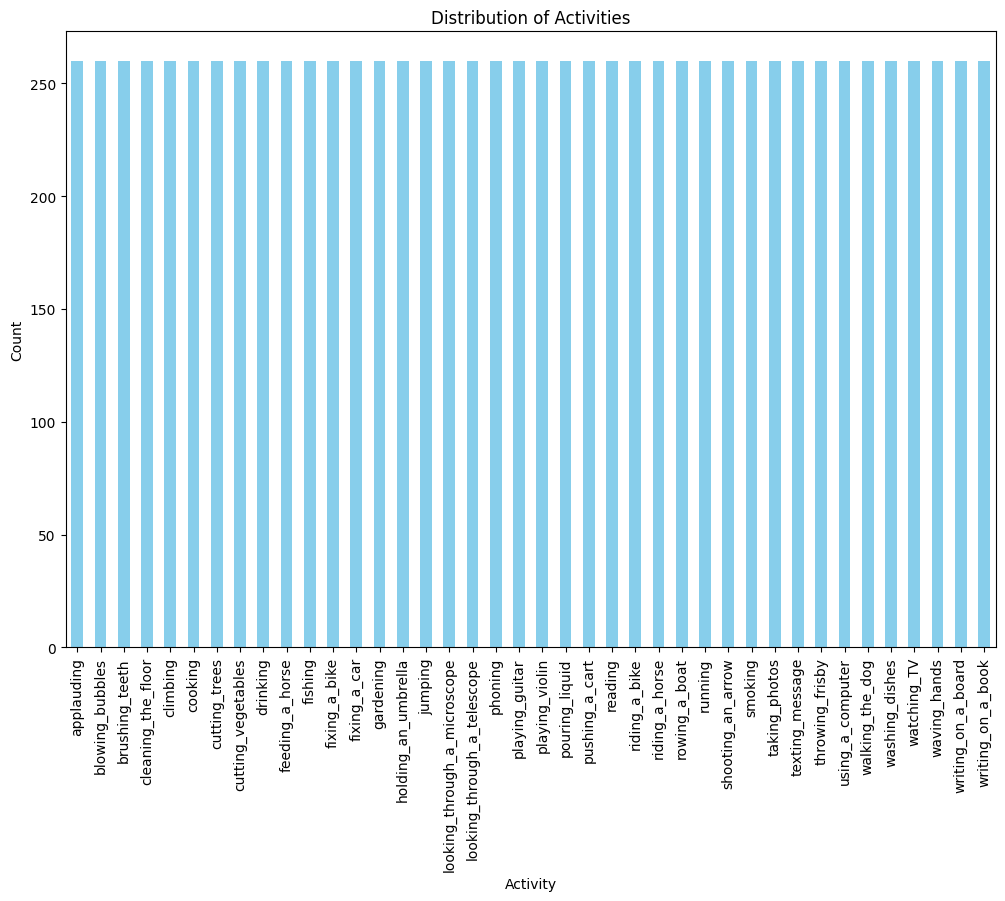

In [13]:

value_counts = df_resampled['Class'].value_counts()
plt.figure(figsize=(12, 8))
value_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Activities')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x labels to fit them better
plt.show()

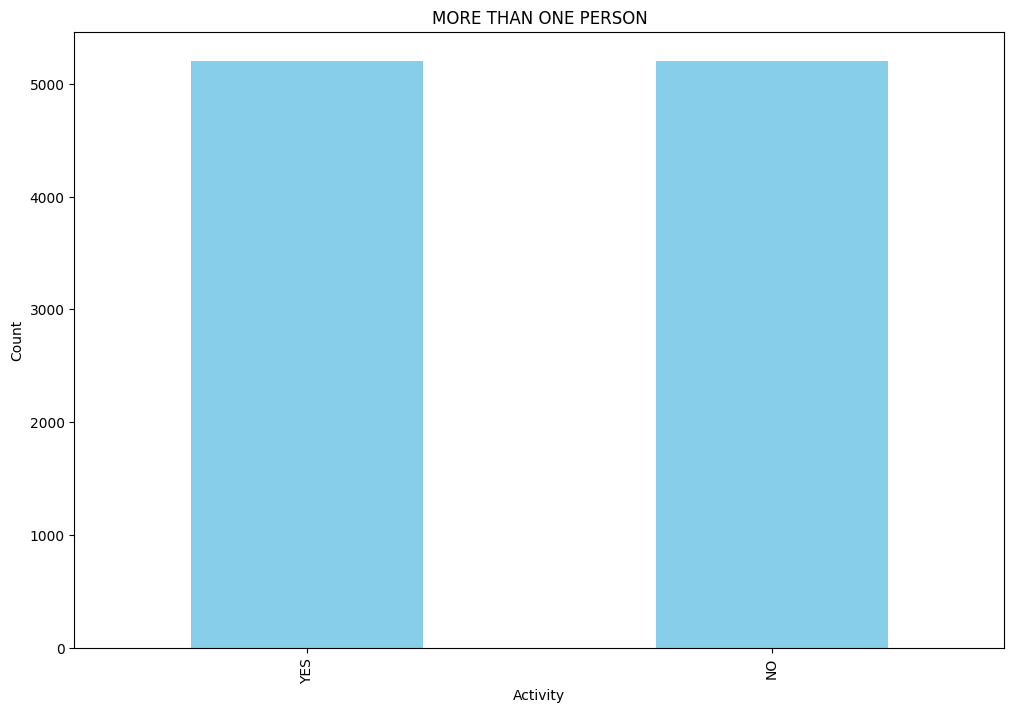

In [14]:
value_counts = df_resampled['MoreThanOnePerson'].value_counts()
plt.figure(figsize=(12, 8))
value_counts.plot(kind='bar', color='skyblue')
plt.title('MORE THAN ONE PERSON')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x labels to fit them better
plt.show()

The Classes are now Balance which would now prevent bias output

The reason I choose OverSampling over underSampling is because in undersampling a lot of datapoints is being removed which results in the model to perform poorly on the test dataset.

In [15]:
df = df_resampled

In [16]:
m = df['FileName'].tolist()

In [17]:
#Converting all the images in the train_df to matrix
images_to_matrix = []
for i in m:
    a = cv2.imread(os.path.join(r"C:\Users\Dell 7490\OneDrive\Desktop\papa world/Images",str(i)))
    images_to_matrix.append(a)

In [18]:
print(images_to_matrix[10].shape)
print(images_to_matrix[1].shape)
images_to_matrix[4].shape

(200, 200, 3)
(300, 200, 3)


(300, 451, 3)

We can clearly see that the size of the Images are different so in order for the images to be put into a CNN model we need to have consistant shape.Thats why we use cv2.resize to resize all the images into a specific size

In [19]:
#Scaling the matrixes between the range 0 to 1 which helps the model to perform better
scaled_matrix = []
for i in range(0,len(images_to_matrix)):
    scaled_matrix.append(images_to_matrix[i]/255)

In [20]:
#Resizing the matrix
resized_matrix = []

for img in scaled_matrix:
    resized_img = cv2.resize(img, (250,250))
    resized_matrix.append(resized_img)

In [21]:
resized_matrix =np.array(resized_matrix)
x= resized_matrix

In [22]:
df_onehot = pd.get_dummies(df['Class'],drop_first=True)
result = pd.concat([df,df_onehot],axis = 1)
df = result.drop('Class',axis = 1)
df['MoreThanOnePerson'] = df['MoreThanOnePerson'].replace({'YES':1,'NO':0})

Since the 'Class' column is categorical we have to convert them into some numeric representation so that it can be fed in the CNN Model.Since its a nominal column we used one hot encoding

In [23]:
df.head()

,FileName,MoreThanOnePerson,blowing_bubbles,brushing_teeth,cleaning_the_floor,climbing,cooking,cutting_trees,cutting_vegetables,drinking,...,taking_photos,texting_message,throwing_frisby,using_a_computer,walking_the_dog,washing_dishes,watching_TV,waving_hands,writing_on_a_board,writing_on_a_book
0,Img_1833.jpg,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Img_9481.jpg,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Img_4182.jpg,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Img_4146.jpg,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Img_244.jpg,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [24]:
y_class = df_onehot.values
y_more_than_one_person = df['MoreThanOnePerson'].values

In [25]:
#Importing some Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,ReLU,Conv2D,MaxPooling2D,Flatten,Dropout,Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Sequential, models, layers
from tensorflow.keras.layers import Dense, Dropout, Flatten


from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import optimizers

In [26]:
#Pre trained VGG16 Model
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(250,250,3))
base_model.trainable = False ## Not trainable weights

58889256/58889256 [==============================] - 0s 0us/step


We use VG16 pre trained model because we dont have enough images to train the CNN model.(Transfer learning)

In [27]:

from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# Define the input
inputs = Input(shape=(250, 250, 3))

# Passing the images through the base model
x = base_model(inputs, training=False)

# Flattening the output
x = Flatten()(x)

# Adding a Dropout layer
x = Dropout(0.5)(x)

# Adding Dense layers with L2 regularization to prevent Overfitting
class_output = Dense(len(df_onehot.columns), activation='softmax',
                     kernel_regularizer=l2(0.01), name='class_output')(x)
person_output = Dense(1, activation='sigmoid',
                      kernel_regularizer=l2(0.01), name='person_output')(x)

# Define the model
model = Model(inputs=inputs, outputs=[class_output, person_output])

In [28]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss={
        'class_output': 'categorical_crossentropy',
        'person_output': 'binary_crossentropy'
    },
    metrics={
        'class_output': 'accuracy',
        'person_output': 'accuracy'
    }
)

In [29]:
# Train the model
model_history = model.fit(
    resized_matrix,
    {'class_output': y_class, 'person_output': y_more_than_one_person},
    epochs=5,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)]
)

Epoch 1/5
325/325 [==============================] - 220s 673ms/step - loss: 3.1195 - class_output_loss: 1.3886 - person_output_loss: 0.4979 - class_output_accuracy: 0.6388 - person_output_accuracy: 0.7559
Epoch 2/5
325/325 [==============================] - 220s 678ms/step - loss: 2.0145 - class_output_loss: 0.4612 - person_output_loss: 0.3263 - class_output_accuracy: 0.8633 - person_output_accuracy: 0.8629
Epoch 3/5
325/325 [==============================] - 221s 679ms/step - loss: 2.0033 - class_output_loss: 0.4034 - person_output_loss: 0.2915 - class_output_accuracy: 0.8791 - person_output_accuracy: 0.8801
Epoch 4/5
325/325 [==============================] - 220s 678ms/step - loss: 2.2278 - class_output_loss: 0.4482 - person_output_loss: 0.2758 - class_output_accuracy: 0.8626 - person_output_accuracy: 0.8892
Epoch 5/5
325/325 [==============================] - 220s 677ms/step - loss: 2.3670 - class_output_loss: 0.4365 - person_output_loss: 0.2752 - class_output_accuracy: 0.8630 - p


AFter the 5 epochs the accuaracy came pretty good at around 86% on the Class prediction and 88 % on the MoreThanOnePerson prediction

1/1 [==============================] - 0s 80ms/step


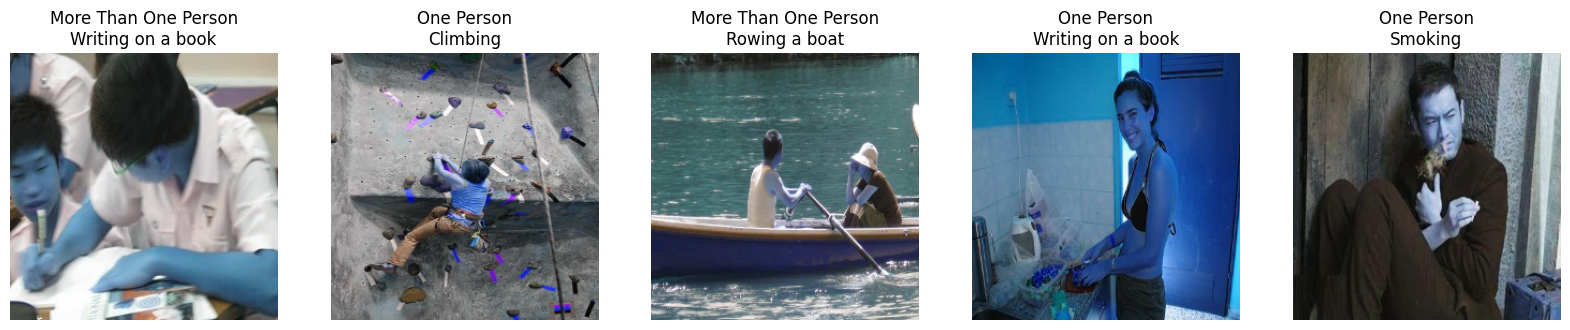

In [30]:
# Defining the directory and filenames for the images
directory = r"C:\Users\Dell 7490\OneDrive\Desktop\papa world/Images"
filenames = ['Img_1746.jpg', 'Img_3.jpg', 'Img_5437.jpg', 'Img_648.jpg', 'Img_7434.jpg']  # Images to be displayed

# Define the activity labels in a list
activities = [
    'Blowing bubbles', 'Brushing teeth', 'Cleaning the Floor', 'Climbing', 'Cooking',
    'Cutting trees', 'Cutting vegetables', 'Drinking', 'Feeding a horse', 'Fishing',
    'Fixing a bike', 'Fixing a car', 'Gardening', 'Holding an umbrella', 'Jumping',
    'Looking through a microscope', 'Looking through a telescope', 'Phoning',
    'Playing guitar', 'Playing violin', 'Pouring liquid', 'Pushing a cart', 'Reading',
    'Riding a bike', 'Riding a horse', 'Rowing a boat', 'Running', 'Shooting an arrow',
    'Smoking', 'Taking photos', 'Texting message', 'Throwing frisby', 'Using a computer',
    'Walking the dog', 'Washing dishes', 'Watching TV', 'Waving hands', 'Writing on a board',
    'Writing on a book'
]

# Initialize lists to store images and predictions
images = []
class_predictions = []
person_predictions = []

# Load and preprocess each image
for filename in filenames:
    img_path = os.path.join(directory, filename)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (250, 250))
    img = img / 255.0
    images.append(img)
    img = np.expand_dims(img, axis=0)

    # Get predictions
    predictions = model.predict(img)

    # Extract predictions for each output
    class_prediction = predictions[0]
    person_prediction = predictions[1]

    # Convert predictions to labels
    class_prediction_label = np.argmax(class_prediction, axis=1)[0]
    person_prediction_label = (person_prediction > 0.5).astype(int)[0]

    class_predictions.append(class_prediction_label)
    person_predictions.append(person_prediction_label)

# Plot the images with predictions
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, ax in enumerate(axes):
    img = images[i]
    class_label = class_predictions[i]
    person_label = person_predictions[i]

    ax.imshow(img)
    ax.axis('off')

    # Print prediction for the number of people
    person_text = 'More Than One Person' if person_label == 1 else 'One Person'

    # Print prediction for the class activity
    activity_text = activities[class_label] if 0 <= class_label < len(activities) else 'Unknown activity'

    ax.set_title(f'{person_text}\n{activity_text}')

plt.show()

The Test Classification looks pretty good !! (ON THE TRAINING CSV)

NOW I I WILL TEST ON THE TEST CSV (I will use random 5 images for testing because I dont have enough creds to run the full test csv file.

In [31]:
test_df = pd.read_csv('train_data_2024_test.csv')
test_df

,FileName,Class,MoreThanOnePerson,HighLevelCategory
0,Img_3985.jpg,applauding,YES,Social_LeisureActivities
1,Img_5468.jpg,applauding,YES,Social_LeisureActivities
2,Img_6728.jpg,applauding,YES,Social_LeisureActivities
3,Img_7616.jpg,applauding,YES,Social_LeisureActivities
4,Img_609.jpg,applauding,YES,Social_LeisureActivities
...,...,...,...,...
913,Img_5621.jpg,writing_on_a_book,YES,Artistic_MusicalActivities
914,Img_8506.jpg,writing_on_a_book,NO,Artistic_MusicalActivities
915,Img_3779.jpg,writing_on_a_book,NO,Artistic_MusicalActivities
916,Img_5192.jpg,writing_on_a_book,NO,Artistic_MusicalActivities


In [40]:
random_rows = df.sample(n=5)
filenames = random_rows['FileName']
filenames

,FileName
6332,Img_1256.jpg
1793,Img_3472.jpg
8334,Img_9302.jpg
6223,Img_5201.jpg
4875,Img_6328.jpg


1/1 [==============================] - 0s 82ms/step


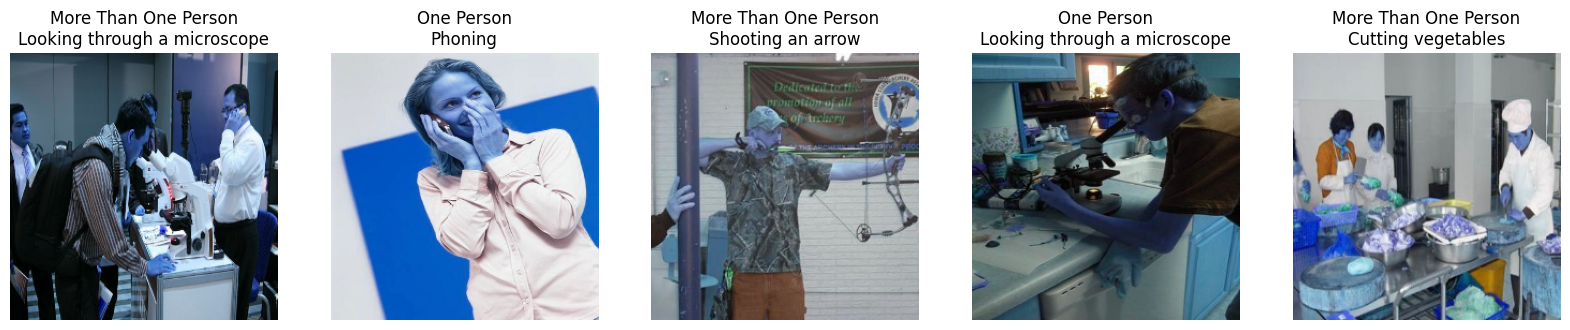

In [41]:
directory = r"C:\Users\Dell 7490\OneDrive\Desktop\papa world/Images"
# Define the activity labels in a list
activities = [
    'Blowing bubbles', 'Brushing teeth', 'Cleaning the Floor', 'Climbing', 'Cooking',
    'Cutting trees', 'Cutting vegetables', 'Drinking', 'Feeding a horse', 'Fishing',
    'Fixing a bike', 'Fixing a car', 'Gardening', 'Holding an umbrella', 'Jumping',
    'Looking through a microscope', 'Looking through a telescope', 'Phoning',
    'Playing guitar', 'Playing violin', 'Pouring liquid', 'Pushing a cart', 'Reading',
    'Riding a bike', 'Riding a horse', 'Rowing a boat', 'Running', 'Shooting an arrow',
    'Smoking', 'Taking photos', 'Texting message', 'Throwing frisby', 'Using a computer',
    'Walking the dog', 'Washing dishes', 'Watching TV', 'Waving hands', 'Writing on a board',
    'Writing on a book'
]

# Initialize lists to store images and predictions
images = []
class_predictions = []
person_predictions = []

# Load and preprocess each image
for filename in filenames:
    img_path = os.path.join(directory, filename)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (250, 250))
    img = img / 255.0
    images.append(img)
    img = np.expand_dims(img, axis=0)

    # Get predictions
    predictions = model.predict(img)

    # Extract predictions for each output
    class_prediction = predictions[0]
    person_prediction = predictions[1]

    # Convert predictions to labels
    class_prediction_label = np.argmax(class_prediction, axis=1)[0]
    person_prediction_label = (person_prediction > 0.5).astype(int)[0]

    class_predictions.append(class_prediction_label)
    person_predictions.append(person_prediction_label)

# Plot the images with predictions
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, ax in enumerate(axes):
    img = images[i]
    class_label = class_predictions[i]
    person_label = person_predictions[i]

    ax.imshow(img)
    ax.axis('off')

    # Print prediction for the number of people
    person_text = 'More Than One Person' if person_label == 1 else 'One Person'

    # Print prediction for the class activity
    activity_text = activities[class_label] if 0 <= class_label < len(activities) else 'Unknown activity'

    ax.set_title(f'{person_text}\n{activity_text}')

plt.show()

The Predictions on the unseen data looks pretty ACCURATE!!!

# LETS WORK WITH THE FUTURE DATA CSV

In [34]:
future_df = pd.read_csv('future_data_2024.csv') #This df only has the filenames
future_df.head()

,FileName
0,Img_1963.jpg
1,Img_7244.jpg
2,Img_6218.jpg
3,Img_7703.jpg
4,Img_6318.jpg


In [35]:
directory = r"C:\Users\Dell 7490\OneDrive\Desktop\papa world/Images"
FILENAMES = future_df['FileName']

In [36]:
import os
import cv2
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# Initialize lists to store the predictions
class_predictions = []
person_predictions = []

# Load and preprocess each image
for filename in FILENAMES:
    img_path = os.path.join(directory, filename)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (250, 250))  # Resize the image as per your model's input size
    img = img / 255.0  # Normalize the image
    img = np.expand_dims(img, axis=0)  # Expand dimensions to match the model input

    # Get predictions from the model
    predictions = model.predict(img)

    # Extract predictions for each output
    class_prediction = predictions[0]
    person_prediction = predictions[1]

    # Convert predictions to labels
    class_prediction_label = np.argmax(class_prediction, axis=1)[0]
    person_prediction_label = (person_prediction > 0.5).astype(int)[0]

    # Append predictions to lists
    class_predictions.append(class_prediction_label)
    person_predictions.append(person_prediction_label)

# Create a new DataFrame with FileName, Class, and MoreThanOnePerson predictions
pred_df = pd.DataFrame({
    'FileName': FILENAMES,
    'Class': [activities[label] for label in class_predictions],  # Convert class index to activity label
    'MoreThanOnePerson': ['Yes' if label == 1 else 'No' for label in person_predictions]  # Convert 0/1 to No/Yes
})

# Display the new DataFrame
pred_df.head()

# Save the predictions to a new CSV file if needed
pred_df.to_csv('s3983534_predictions.csv', index=False)

1/1 [==============================] - 0s 77ms/step


In [37]:
pred_df = pd.read_csv('s3983534_predictions.csv')
pred_df.head()

,FileName,Class,MoreThanOnePerson
0,Img_1963.jpg,Drinking,No
1,Img_7244.jpg,Gardening,No
2,Img_6218.jpg,Riding a horse,Yes
3,Img_7703.jpg,Brushing teeth,No
4,Img_6318.jpg,Climbing,No


I have noticed one thing that is my model seems to struggle to predict on the applauding class it could be due to several unknown reasons but in my opinion it could be due to the complexity of the image as applauding looks pretty close to other images classes like waving hands ,pushing etc.Additionally it could also be due to less applauding images in the dataset and due to that the model isnt trained well enough to identify the class.

ETHICAL CHALLENGES AND BIASES

Ethical Challenges
1. Privacy Concerns: HAR technology often involves continuous monitoring, raising issues about user consent and data privacy.

2. Surveillance Risks: Increased data collection can lead to misuse, such as unauthorized surveillance or tracking.

3. Transparency: Lack of transparency in data collection methods and algorithms can erode user trust.

BIASES

1. Demographic Representation: Underrepresentation of certain demographics (e.g., disabled individuals,race,gender) can lead to biased models.

2. Activity Variation: Inconsistent activity types or environments can limit the model's ability to generalize across different contexts.(Eg having one activity occuring far more time in a dataset)